
# Análisis Multivariado de Varianza
## Ejemplo: Comparación de Métodos de Enseñanza
## Actividad MANOVA
### Dr. Hugo García Tecocoatzi

In [1]:
# Bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.datasets import load_iris, load_wine, load_diabetes # Necesaria para la actividad
from scipy.stats import f_oneway
from statsmodels.multivariate.manova import MANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import statsmodels.api as sm
from statsmodels.formula.api import ols

%matplotlib inline

In [2]:
# Generar datos sintéticos para el ejemplo
np.random.seed(42)

# Parámetros
n_por_grupo = 30
grupos = ['A', 'B', 'C']

# Método A: Enseñanza tradicional
# Matemáticas: media 75, Lectura: media 70
mat_A = np.random.normal(75, 8, n_por_grupo)
lec_A = np.random.normal(70, 8, n_por_grupo)

# Método B: Enseñanza activa
# Matemáticas: media 82, Lectura: media 78
mat_B = np.random.normal(82, 8, n_por_grupo)
lec_B = np.random.normal(78, 8, n_por_grupo)

# Método C: Enseñanza híbrida
# Matemáticas: media 78, Lectura: media 75
mat_C = np.random.normal(78, 8, n_por_grupo)
lec_C = np.random.normal(75, 8, n_por_grupo)

# Crear DataFrame
df = pd.DataFrame({
    'Metodo': ['A']*n_por_grupo + ['B']*n_por_grupo + ['C']*n_por_grupo,
    'Matematicas': np.concatenate([mat_A, mat_B, mat_C]),
    'Lectura': np.concatenate([lec_A, lec_B, lec_C])
})

# Asegurar que las calificaciones estén en rango [0, 100]
df['Matematicas'] = np.clip(df['Matematicas'], 0, 100)
df['Lectura'] = np.clip(df['Lectura'], 0, 100)

print("Datos generados exitosamente")
print(f"Forma del dataset: {df.shape}")
print(f"Grupos: {df['Metodo'].unique()}")
df.head(10)

Datos generados exitosamente
Forma del dataset: (90, 3)
Grupos: <StringArray>
['A', 'B', 'C']
Length: 3, dtype: str


,Metodo,Matematicas,Lectura
0,A,78.973713,65.186347
1,A,73.893886,84.818225
2,A,80.181508,69.892022
3,A,87.184239,61.538313
4,A,73.126773,76.580359
5,A,73.126904,60.233251
6,A,87.633703,71.670909
7,A,81.139478,54.322639
8,A,71.244205,59.374512
9,A,79.340480,71.574890


In [3]:
#  Estadísticas descriptivas por grupo
print("ESTADÍSTICAS DESCRIPTIVAS POR GRUPO: \n")

estadisticas = df.groupby('Metodo').agg({
    'Matematicas': ['mean', 'std', 'min', 'max'],
    'Lectura': ['mean', 'std', 'min', 'max']
}).round(2)

print(estadisticas)

ESTADÍSTICAS DESCRIPTIVAS POR GRUPO: 

       Matematicas                     Lectura                    
              mean   std    min    max    mean   std    min    max
Metodo                                                            
A            73.49  7.20  59.69  87.63   69.03  7.45  54.32  84.82
B            82.10  7.94  61.04  94.52   77.84  7.27  62.65  97.71
C            77.24  8.19  65.14  95.52   77.23  7.58  65.47  96.76


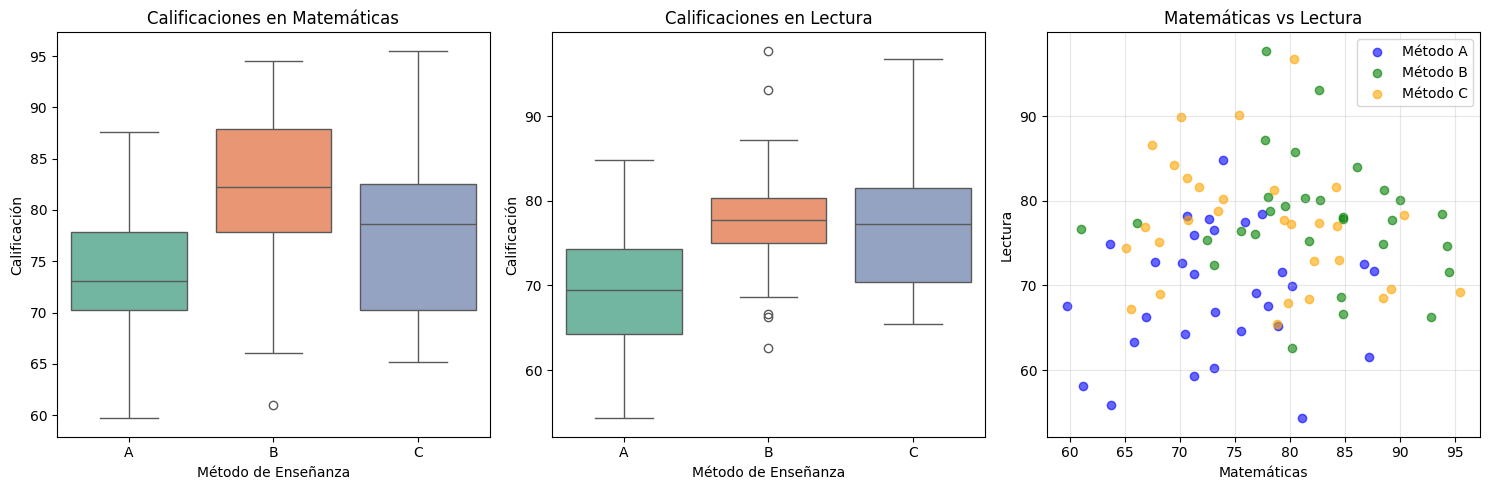

In [4]:
# Visualización 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boxplot Matemáticas
sns.boxplot(x='Metodo', y='Matematicas', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Calificaciones en Matemáticas')
axes[0].set_xlabel('Método de Enseñanza')
axes[0].set_ylabel('Calificación')

# Boxplot Lectura
sns.boxplot(x='Metodo', y='Lectura', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Calificaciones en Lectura')
axes[1].set_xlabel('Método de Enseñanza')
axes[1].set_ylabel('Calificación')

# Scatter plot Matemáticas vs Lectura
colors = {'A': 'blue', 'B': 'green', 'C': 'orange'}
for metodo in df['Metodo'].unique():
    subset = df[df['Metodo'] == metodo]
    axes[2].scatter(subset['Matematicas'], subset['Lectura'], 
                    alpha=0.6, label=f'Método {metodo}', color=colors[metodo])
axes[2].set_xlabel('Matemáticas')
axes[2].set_ylabel('Lectura')
axes[2].set_title('Matemáticas vs Lectura')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

MATRIZ DE CORRELACIÓN

             Matematicas  Lectura
Matematicas       1.0000   0.0886
Lectura           0.0886   1.0000


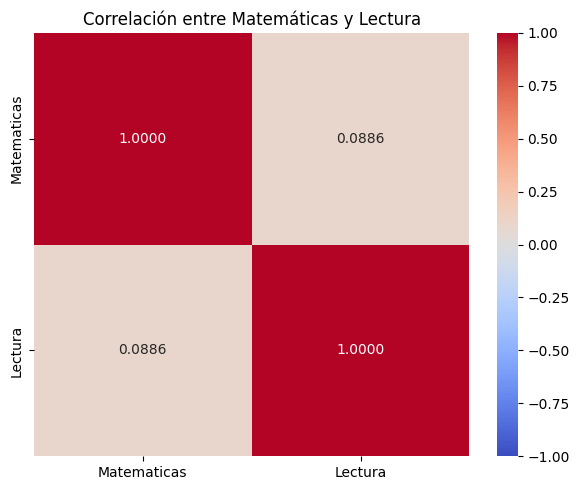

In [5]:
# Matriz de correlación
print("MATRIZ DE CORRELACIÓN\n")
print(df[['Matematicas', 'Lectura']].corr().round(4))

# Visualización
plt.figure(figsize=(6, 5))
sns.heatmap(df[['Matematicas', 'Lectura']].corr(), 
            annot=True, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, fmt='.4f')
plt.title('Correlación entre Matemáticas y Lectura')
plt.tight_layout()
plt.show()

In [6]:
#  MANOVA - Prueba principal
print("MANOVA \n")

# Ajustar MANOVA
manova = MANOVA.from_formula('Matematicas + Lectura ~ Metodo', data=df)
resultado = manova.mv_test()

print(resultado)

MANOVA 

                   Multivariate linear model
                                                               
---------------------------------------------------------------
       Intercept         Value  Num DF  Den DF  F Value  Pr > F
---------------------------------------------------------------
          Wilks' lambda  0.0146 2.0000 86.0000 2907.3547 0.0000
         Pillai's trace  0.9854 2.0000 86.0000 2907.3547 0.0000
 Hotelling-Lawley trace 67.6129 2.0000 86.0000 2907.3547 0.0000
    Roy's greatest root 67.6129 2.0000 86.0000 2907.3547 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
           Metodo         Value  Num DF  Den DF  F Value Pr > F
---------------------------------------------------------------
            Wilks' lambda 0.6317 4.0000 172.0000 11.1040 0.0000
           Pillai's trace 0.3790 4.0000 174.0000 1

In [7]:
#  Extraer resultados de los cuatro estadísticos
print("=== RESULTADOS DE LOS CUATRO ESTADÍSTICOS ===\n")

# Extraer resultados del MANOVA
resultados_mv = manova.mv_test().results['Metodo']['stat']

print("Estadísticos de prueba:")
print(resultados_mv.round(4))

=== RESULTADOS DE LOS CUATRO ESTADÍSTICOS ===

Estadísticos de prueba:
                           Value Num DF      Den DF    F Value Pr > F
Wilks' lambda           0.631651      4       172.0  11.104044    0.0
Pillai's trace          0.379027    4.0       174.0  10.171469    0.0
Hotelling-Lawley trace  0.566246      4  102.169014  12.128592    0.0
Roy's greatest root     0.534625      2          87  23.256178    0.0


In [8]:
# Interpretación de resultados
print("=== INTERPRETACIÓN DE RESULTADOS ===\n")

# Verificar significancia de cada estadístico
for estadistico in resultados_mv.index:
    if 'p-value' in resultados_mv.columns:
        p_valor = resultados_mv.loc[estadistico, 'Pr > F']
        valor = resultados_mv.loc[estadistico, 'Value']
        
        if p_valor < 0.05:
            print(f"✅ {estadistico}: Valor = {valor:.4f}, p = {p_valor:.4f} → SIGNIFICATIVO")
        else:
            print(f"❌ {estadistico}: Valor = {valor:.4f}, p = {p_valor:.4f} → NO SIGNIFICATIVO")

print("\n Conclusión:")
print("Si todos los estadísticos son significativos (p < 0.05),")
print("existe evidencia de que los métodos de enseñanza difieren")
print("en el patrón conjunto de Matemáticas y Lectura.")

=== INTERPRETACIÓN DE RESULTADOS ===


 Conclusión:
Si todos los estadísticos son significativos (p < 0.05),
existe evidencia de que los métodos de enseñanza difieren
en el patrón conjunto de Matemáticas y Lectura.


In [9]:
# ANOVA univariado post-hoc (con corrección de Bonferroni)
print("=== ANOVA UNIVARIADO POST-HOC ===\n")

# ANOVA para Matemáticas
print("ANOVA para Matemáticas:")
modelo_mat = ols('Matematicas ~ Metodo', data=df).fit()
anova_mat = sm.stats.anova_lm(modelo_mat, typ=2)
print(anova_mat.round(4))

# ANOVA para Lectura
print("\n ANOVA para Lectura:")
modelo_lec = ols('Lectura ~ Metodo', data=df).fit()
anova_lec = sm.stats.anova_lm(modelo_lec, typ=2)
print(anova_lec.round(4))

# Corrección de Bonferroni
alpha = 0.05
alpha_bonferroni = alpha / 2  # 2 variables dependientes

print(f"\n Corrección de Bonferroni:")
print(f"   α original = {alpha}")
print(f"   α ajustado = {alpha_bonferroni}")

# Interpretación
p_mat = anova_mat.loc['Metodo', 'PR(>F)']
p_lec = anova_lec.loc['Metodo', 'PR(>F)']

print(f"\n   Matemáticas: p = {p_mat:.4f} → {'Significativo' if p_mat < alpha_bonferroni else 'No significativo'}")
print(f"   Lectura: p = {p_lec:.4f} → {'Significativo' if p_lec < alpha_bonferroni else 'No significativo'}")

=== ANOVA UNIVARIADO POST-HOC ===

ANOVA para Matemáticas:
             sum_sq    df      F  PR(>F)
Metodo    1117.7714   2.0  9.215  0.0002
Residual  5276.5085  87.0    NaN     NaN

 ANOVA para Lectura:
             sum_sq    df        F  PR(>F)
Metodo    1451.7091   2.0  13.1348     0.0
Residual  4807.8024  87.0      NaN     NaN

 Corrección de Bonferroni:
   α original = 0.05
   α ajustado = 0.025

   Matemáticas: p = 0.0002 → Significativo
   Lectura: p = 0.0000 → Significativo


In [10]:
#  Comparaciones múltiples post-hoc (Tukey HSD)
print(" COMPARACIONES MÚLTIPLES POST-HOC (TUKEY HSD) \n")

# Tukey para Matemáticas
print("Tukey HSD para Matemáticas:")
tukey_mat = pairwise_tukeyhsd(df['Matematicas'], df['Metodo'], alpha=0.05)
print(tukey_mat)

print("\n Tukey HSD para Lectura:")
tukey_lec = pairwise_tukeyhsd(df['Lectura'], df['Metodo'], alpha=0.05)
print(tukey_lec)

 COMPARACIONES MÚLTIPLES POST-HOC (TUKEY HSD) 

Tukey HSD para Matemáticas:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B   8.6083 0.0001  3.8136 13.403   True
     A      C   3.7455 0.1558 -1.0492 8.5402  False
     B      C  -4.8627 0.0461 -9.6574 -0.068   True
---------------------------------------------------

 Tukey HSD para Lectura:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B   8.8073    0.0  4.2305 13.3841   True
     A      C   8.1996 0.0001  3.6228 12.7764   True
     B      C  -0.6077 0.9463 -5.1845  3.9691  False
----------------------------------------------------


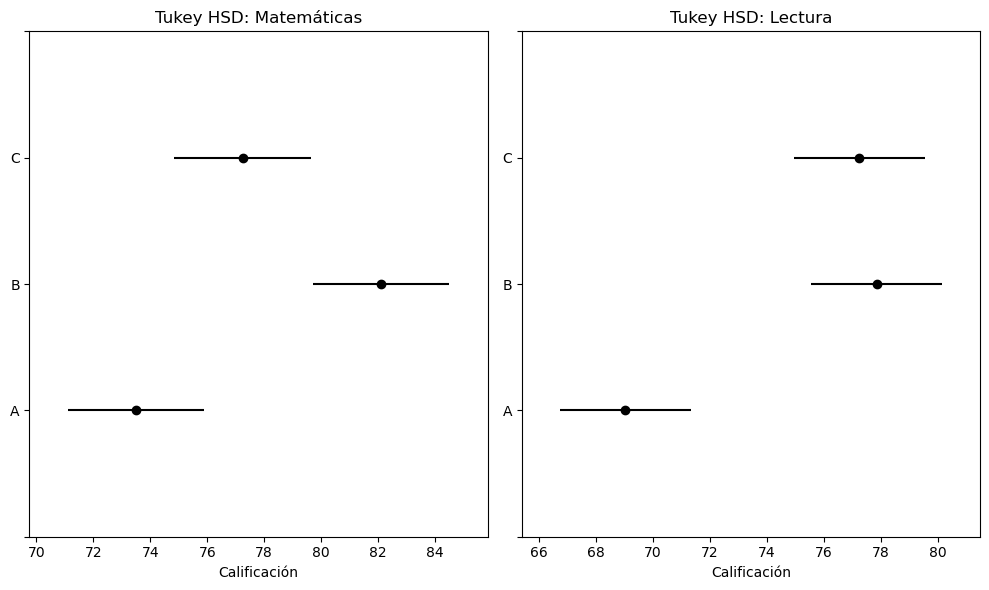

In [11]:
# Visualización de Tukey HSD
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tukey Matemáticas
tukey_mat.plot_simultaneous(ax=axes[0])
axes[0].set_title('Tukey HSD: Matemáticas')
axes[0].set_xlabel('Calificación')

# Tukey Lectura
tukey_lec.plot_simultaneous(ax=axes[1])
axes[1].set_title('Tukey HSD: Lectura')
axes[1].set_xlabel('Calificación')

plt.tight_layout()
plt.show()

In [12]:
# Verificación de supuestos - Normalidad multivariada
print("=== VERIFICACIÓN DE SUPUESTOS ===\n")
print("--- Normalidad Multivariada ---\n")

# Test de Mardia para normalidad multivariada
def mardia_test(data, alpha=0.05):
    """
    Implementación simplificada del test de Mardia
    """
    n, p = data.shape
    mean = np.mean(data, axis=0)
    centered = data - mean
    S = np.cov(data, rowvar=False)
    S_inv = np.linalg.inv(S)
    
    # Asimetría multivariada
    b1p = 0
    for i in range(n):
        for j in range(n):
            b1p += (centered[i] @ S_inv @ centered[j])**3
    b1p = b1p / (n**2)
    
    # Curtosis multivariada
    b2p = 0
    for i in range(n):
        b2p += (centered[i] @ S_inv @ centered[i])**2
    b2p = b2p / n
    
    # Estadísticos de prueba
    skewness_stat = n * b1p / 6
    kurtosis_stat = (b2p - p*(p+2)) / np.sqrt(8*p*(p+2)/n)
    
    # p-valores
    p_skewness = 1 - stats.chi2.cdf(skewness_stat, p*(p+1)*(p+2)/6)
    p_kurtosis = 2 * (1 - stats.norm.cdf(abs(kurtosis_stat)))
    
    return {
        'Skewness statistic': skewness_stat,
        'Skewness p-value': p_skewness,
        'Kurtosis statistic': kurtosis_stat,
        'Kurtosis p-value': p_kurtosis
    }

# Aplicar test por grupo
for metodo in df['Metodo'].unique():
    subset = df[df['Metodo'] == metodo][['Matematicas', 'Lectura']].values
    print(f"Método {metodo}:")
    resultado = mardia_test(subset)
    for key, value in resultado.items():
        print(f"  {key}: {value:.4f}")
    
    if resultado['Skewness p-value'] > 0.05 and resultado['Kurtosis p-value'] > 0.05:
        print("  ✅ Normalidad multivariada aceptable")
    else:
        print("  ⚠️ Posible violación de normalidad multivariada")
    print()

=== VERIFICACIÓN DE SUPUESTOS ===

--- Normalidad Multivariada ---

Método A:
  Skewness statistic: 1.9333
  Skewness p-value: 0.7480
  Kurtosis statistic: -1.1241
  Kurtosis p-value: 0.2610
  ✅ Normalidad multivariada aceptable

Método B:
  Skewness statistic: 4.0213
  Skewness p-value: 0.4031
  Kurtosis statistic: -0.2271
  Kurtosis p-value: 0.8203
  ✅ Normalidad multivariada aceptable

Método C:
  Skewness statistic: 3.1460
  Skewness p-value: 0.5337
  Kurtosis statistic: -0.9106
  Kurtosis p-value: 0.3625
  ✅ Normalidad multivariada aceptable



In [13]:
#  Verificación de supuestos - Homogeneidad de covarianzas (Box's M)
print(" Homogeneidad de Matrices de Covarianza (Box's M) \n")

def box_m_test(data, groups):
    """
    Implementación del test M de Box
    """
    group_names = groups.unique()
    k = len(group_names)
    p = data.shape[1]
    
    # Tamaños de muestra
    ns = [len(data[groups == g]) for g in group_names]
    n_total = sum(ns)
    
    # Matrices de covarianza por grupo
    covs = []
    for g in group_names:
        subset = data[groups == g]
        covs.append(np.cov(subset, rowvar=False))
    
    # Covarianza pooled
    pooled_cov = sum([(n-1) * cov for n, cov in zip(ns, covs)]) / (n_total - k)
    
    # Estadístico M
    M = (n_total - k) * np.log(np.linalg.det(pooled_cov))
    for n, cov in zip(ns, covs):
        M -= (n - 1) * np.log(np.linalg.det(cov))
    
    # Factor de corrección
    c = (2 * p**2 + 3 * p - 1) / (6 * (p + 1) * (k - 1))
    c *= sum([1/(n-1) for n in ns]) - 1/(n_total - k)
    
    # Estadístico de prueba
    chi2_stat = M * (1 - c)
    
    # Grados de libertad
    df = p * (p + 1) * (k - 1) / 2
    
    # p-valor
    p_value = 1 - stats.chi2.cdf(chi2_stat, df)
    
    return {
        'M statistic': M,
        'Chi-square': chi2_stat,
        'df': df,
        'p-value': p_value
    }

# Aplicar Box's M
resultado_box = box_m_test(df[['Matematicas', 'Lectura']], df['Metodo'])
print("Resultados del test M de Box:")
for key, value in resultado_box.items():
    print(f"  {key}: {value:.4f}")

if resultado_box['p-value'] > 0.05:
    print("\n✅ No se rechaza H₀: Las matrices de covarianza son homogéneas")
else:
    print("\n⚠️ Se rechaza H₀: Posible violación de homogeneidad de covarianzas")
    print("   → Considerar usar Pillai's Trace (más robusto)")

 Homogeneidad de Matrices de Covarianza (Box's M) 

Resultados del test M de Box:
  M statistic: 2.3240
  Chi-square: 2.2469
  df: 6.0000
  p-value: 0.8957

✅ No se rechaza H₀: Las matrices de covarianza son homogéneas


In [14]:
#  Preguntas de análisis
print(" PREGUNTAS DE ANÁLISIS:")
print("\n1. ¿Cuál de los cuatro estadísticos MANOVA es más apropiado y por qué?")
print("2. ¿Qué variable dependiente contribuye más a las diferencias entre grupos?")
print("3. ¿Qué pares de grupos son significativamente diferentes?")
print("4. ¿Se cumplen los supuestos del MANOVA? ¿Qué implicaciones tiene?")
print("5. ¿Cómo se relacionan los resultados del LDA con los del MANOVA?")



 PREGUNTAS DE ANÁLISIS:

1. ¿Cuál de los cuatro estadísticos MANOVA es más apropiado y por qué?
2. ¿Qué variable dependiente contribuye más a las diferencias entre grupos?
3. ¿Qué pares de grupos son significativamente diferentes?
4. ¿Se cumplen los supuestos del MANOVA? ¿Qué implicaciones tiene?
5. ¿Cómo se relacionan los resultados del LDA con los del MANOVA?


 Escribe tus respuestas aquí:

# Actividad MANOVA

Ahora repite todo para el siguiente dataset de load_iris

In [15]:
# Celda 3: Cargar el dataset Iris (datos reales)
# El dataset Iris contiene mediciones de 3 especies de flores
iris = load_iris()

# Crear DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Especie'] = iris.target_names[iris.target]

# Renombrar columnas para claridad
df.columns = ['Longitud_Sepalo', 'Ancho_Sepalo', 
              'Longitud_Petalo', 'Ancho_Petalo', 'Especie']

print(f"Forma del dataset: {df.shape}")
print(f"Especies: {df['Especie'].unique()}")
print(f"Observaciones por especie:")
print(df['Especie'].value_counts())
df.head(10)

Forma del dataset: (150, 5)
Especies: ['setosa' 'versicolor' 'virginica']
Observaciones por especie:
Especie
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,Longitud_Sepalo,Ancho_Sepalo,Longitud_Petalo,Ancho_Petalo,Especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa
